# `reionemu` Package Example Usage

This notebook is a **full package tour** for `reionemu`.  
It is designed to demonstrate:

- the **public API**
- the **end-to-end pipeline**
- the **main configuration objects**
- the **return objects** from each major function
- the **model classes**
- the **training** and **k-fold cross-validation** utilities


## Pipeline covered in this notebook

The package naturally forms a pipeline:

1. **Condense raw simulation outputs** into a single HDF5 file  
2. **Compute angular power spectra** and write `/cl` products into the condensed file  
3. **Build ML-ready arrays** `X`, `Y`, and `ell`  
4. **Create DataLoaders** and optional normalization objects  
5. **Instantiate emulator models**  
6. **Train a model** with `fit()`  
7. **Evaluate with K-Fold cross-validation**

This notebook is structured in exactly that order.

## Package Imports & Organization

Import from the top-level package (after `pip install reionemu`). The library is organized into:

- **reionemu.simio** — Condense raw outputs, compute power spectra, build training arrays
- **reionemu.data** — Dataloaders and normalization
- **reionemu.models** — Baseline emulators (`FourParamEmulator`, `ThreeParamEmulator`) and **reionemu.models.experimental** for POC variants
- **reionemu.training** — `fit()` and `kfold_cross_validate()`

In [1]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "retina"
plt.rcParams.update({ "figure.dpi": 150 })

import reionemu as remu
print(remu.__all__)

['condense_sim_root', 'CondenseConfig', 'CondenseStats', 'add_cl_to_condensed_h5', 'ClConfig', 'build_and_write_training', 'build_training_arrays', 'BuildXYConfig', 'BuildStats', 'make_dataloaders', 'load_training_arrays', 'DataLoaderConfig', 'Normalizer', 'FourParamEmulator', 'ThreeParamEmulator', 'fit', 'FitConfig', 'kfold_cross_validate', 'KFoldConfig']


## Public API summary

The package root is set up to expose the main functions, configs, and model classes directly.
That means users can often stay at the top-level namespace instead of importing deeply from submodules.

The main groups are:

- **Simulation I/O**
  - `condense_sim_root`
  - `add_cl_to_condensed_h5`
  - `build_training_arrays`
  - `build_and_write_training`

- **Data utilities**
  - `load_training_arrays`
  - `make_dataloaders`
  - `Normalizer`

- **Models**
  - `FourParamEmulator`
  - `ThreeParamEmulator`

- **Training**
  - `fit`
  - `kfold_cross_validate`

## Set your file paths

Update these paths before running the pipeline cells below.

- `raw_sim_root` should point to the directory containing simulation folders like `sim1`, `sim2`, ...
- `condensed_h5` is the combined output file used throughout the rest of the notebook

In [2]:
raw_sim_root = Path(r"/Users/robertxpearce/Desktop/reionization-emulator/data/raw/sims_v6")
condensed_h5 = Path(r"/Users/robertxpearce/Desktop/reionization-emulator/data/processed/TEST.h5")

print("raw_sim_root =", raw_sim_root)
print("condensed_h5 =", condensed_h5)

raw_sim_root = /Users/robertxpearce/Desktop/reionization-emulator/data/raw/sims_v6
condensed_h5 = /Users/robertxpearce/Desktop/reionization-emulator/data/processed/TEST.h5


# 1. Condense raw simulation outputs

The first stage scans a root directory of simulation folders and creates a single condensed HDF5 file.

### Main function
- `remu.condense_sim_root(...)`

### Main config
- `remu.CondenseConfig(overwrite=True, require_obs_and_pk=True)`

### Return object
- `CondenseStats`
  - `written`
  - `skipped_missing_obs_pk`
  - `skipped_read_error`
  - `skipped_validation_error`
  - property: `skipped_total`

In [3]:
%%time

condense_config = remu.CondenseConfig(
    overwrite=True,
    require_obs_and_pk=True,
)

condense_stats = remu.condense_sim_root(
    sim_root=raw_sim_root,
    out_path=condensed_h5,
    config=condense_config,
)

print(condense_stats)
print("Total Skipped:", condense_stats.skipped_total)

CondenseStats(written=1000, skipped_missing_obs_pk=0, skipped_read_error=0, skipped_validation_error=0)
Total Skipped: 0
CPU times: user 1.15 s, sys: 7.11 s, total: 8.25 s
Wall time: 14.2 s


# 2. Compute and attach angular power spectra

After condensation, the next stage computes the flat-sky angular power spectrum from each simulation's kSZ map
and writes a `/cl` group for every simulation.

### Main function
- `remu.add_cl_to_condensed_h5(...)`

### Main config
- `remu.ClConfig(nbins=5, ell_cut=1000.0, overwrite=True, sims_group="sims")`

### Return object
- `int` = number of simulations updated

In [4]:
%%time

cl_config = remu.ClConfig(
    nbins=5,
    ell_cut=1000.0,
    overwrite=True,
    sims_group="sims",
)

n_updated = remu.add_cl_to_condensed_h5(
    h5_path=condensed_h5,
    config=cl_config,
)

print("Simulations Updated:", n_updated)

Simulations Updated: 1000
CPU times: user 2min 55s, sys: 2.11 s, total: 2min 57s
Wall time: 3min


# 3. Build machine-learning arrays

This stage constructs the training arrays from the condensed HDF5 file.

### Main functions
- `remu.build_training_arrays(...)`
- `remu.build_and_write_training(...)`

### Main config
- `remu.BuildXYConfig(...)`

### Return objects from `build_training_arrays`
A 6-tuple:

1. `X` — parameter matrix
2. `Y` — target matrix
3. `ell` — ell bin centers
4. `sim_ids` — simulation IDs
5. `param_names` — parameter names used in `X`
6. `BuildStats` — processed/skip statistics

In [5]:
%%time

build_config = remu.BuildXYConfig(
    sims_group="sims",
    params_group="params",
    cl_group="cl",
    param_names=("zmean_zre", "alpha_zre", "kb_zre", "b0_zre"),
    y_source="dl_ksz",
    y_transform="ln",
    eps=1e-30,
)

n_written = remu.build_and_write_training(
    condensed_h5,
    config=build_config,
    overwrite=True,
)

print("Training Samples Written:", n_written)

Training Samples Written: 1000
CPU times: user 223 ms, sys: 29.1 ms, total: 252 ms
Wall time: 372 ms


# 4. Load the training arrays

Once `/training` exists in the condensed HDF5 file, the package can load the arrays directly.

### Main function
- `remu.load_training_arrays(h5_path)`

### Return object
A 3-tuple:

1. `X`
2. `Y`
3. `ell`

In [6]:
%%time

X_loaded, Y_loaded, ell_loaded = remu.load_training_arrays(condensed_h5)

print("X_loaded.shape =", X_loaded.shape)
print("Y_loaded.shape =", Y_loaded.shape)
print("ell_loaded.shape =", ell_loaded.shape)
print("X dtype:", X_loaded.dtype)
print("Y dtype:", Y_loaded.dtype)
print("ell dtype:", ell_loaded.dtype)

X_loaded.shape = (1000, 4)
Y_loaded.shape = (1000, 5)
ell_loaded.shape = (5,)
X dtype: float32
Y dtype: float32
ell dtype: float32
CPU times: user 938 μs, sys: 830 μs, total: 1.77 ms
Wall time: 1.13 ms


# 5. Build DataLoaders

The data-loading utility creates PyTorch DataLoaders from the HDF5 training arrays and can optionally fit/apply normalization using **training split only** statistics.

### Main function
- `remu.make_dataloaders(...)`

### Main config
- `remu.DataLoaderConfig(...)`

### Return object
A 3-tuple:

1. `loaders` — dict of `torch.utils.data.DataLoader` objects keyed by split name
2. `norms` — dict with keys `"X"` and `"Y"`; values are `Normalizer` objects or `None`
3. `ell` — ell bin centers

In [7]:
%%time

dl_config = remu.DataLoaderConfig(
    batch_size=32,
    seed=42,
    shuffle_train=True,
    normalize_X=True,
    normalize_Y=False,
)

loaders, norms, ell_dl = remu.make_dataloaders(
    condensed_h5,
    split={"train": 0.8, "val": 0.2},
    config=dl_config,
)

print("Loader Keys:", list(loaders.keys()))
print("Norm Keys:", list(norms.keys()))
print("ell Dl Shape:", ell_dl.shape)
print("X Normalizer Type:", type(norms["X"]))
print("Y Normalizer Type:", type(norms["Y"]))
if norms["X"] is not None:
    print("X Mean:", norms["X"].mean)
    print("X STD :", norms["X"].std)

if norms["Y"] is not None:
    print("Y Mean:", norms["Y"].mean)
    print("Y STD :", norms["Y"].std)

Loader Keys: ['train', 'val']
Norm Keys: ['X', 'Y']
ell Dl Shape: (5,)
X Normalizer Type: <class 'reionemu.data.normalization.Normalizer'>
Y Normalizer Type: <class 'NoneType'>
X Mean: [7.9963284  0.4994851  1.0572479  0.45696917]
X STD : [0.571093   0.23162802 0.54692036 0.20266293]
CPU times: user 13.4 ms, sys: 3.68 ms, total: 17.1 ms
Wall time: 18 ms


# 7. Model classes

The package currently exposes two PyTorch model classes:

- `remu.FourParamEmulator`
- `remu.ThreeParamEmulator`

Both are straightforward `torch.nn.Module` subclasses.
This section shows:

- how to instantiate them
- what their architectures look like
- the expected input/output shapes
- how many trainable parameters they contain

In [8]:
%%time

four_model = remu.FourParamEmulator()
three_model = remu.ThreeParamEmulator()

print("FourParamEmulator")
print(four_model)
params = sum(params.numel() for params in four_model.parameters() if params.requires_grad)
print("Trainable Params:", params)
print()

print("ThreeParamEmulator")
print(three_model)
params = sum(params.numel() for params in three_model.parameters() if params.requires_grad)
print("Trainable Params:", params)

FourParamEmulator
FourParamEmulator(
  (fc1): Linear(in_features=4, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=5, bias=True)
  (activation): ReLU()
)
Trainable Params: 625

ThreeParamEmulator
ThreeParamEmulator(
  (fc1): Linear(in_features=3, out_features=5, bias=True)
  (out): Linear(in_features=5, out_features=5, bias=True)
  (activation): GELU(approximate='none')
)
Trainable Params: 50
CPU times: user 641 μs, sys: 941 μs, total: 1.58 ms
Wall time: 1.17 ms


# 8. Train a model with `fit()`

The training utility expects:

- a model
- `train_loader`
- `val_loader`
- an optimizer
- a loss function
- a `FitConfig`

### Main function
- `remu.fit(...)`

### Main config
- `remu.FitConfig(...)`

### Return object
A `dict` with:
- `"train_loss"` → list of train losses by epoch
- `"val_loss"` → list of validation losses by epoch

Epoch 001: train=0.343476, val=0.311814
Epoch 002: train=0.238800, val=0.193066
Epoch 003: train=0.142204, val=0.099488
Epoch 004: train=0.073437, val=0.045056
Epoch 005: train=0.037031, val=0.024212
Epoch 006: train=0.023678, val=0.017973
Epoch 007: train=0.018467, val=0.015201
Epoch 008: train=0.015378, val=0.013226
Epoch 009: train=0.013253, val=0.012099
Epoch 010: train=0.011693, val=0.011014
Epoch 011: train=0.010672, val=0.010240
Epoch 012: train=0.009774, val=0.009611
Epoch 013: train=0.009038, val=0.008929
Epoch 014: train=0.008652, val=0.008776
Epoch 015: train=0.008195, val=0.008363
Epoch 016: train=0.007874, val=0.007989
Epoch 017: train=0.007549, val=0.007841
Epoch 018: train=0.007306, val=0.007616
Epoch 019: train=0.007070, val=0.007313
Epoch 020: train=0.006823, val=0.007242
Epoch 021: train=0.006711, val=0.007096
Epoch 022: train=0.006572, val=0.006861
Epoch 023: train=0.006384, val=0.006861
Epoch 024: train=0.006171, val=0.006666
Epoch 025: train=0.006063, val=0.006640


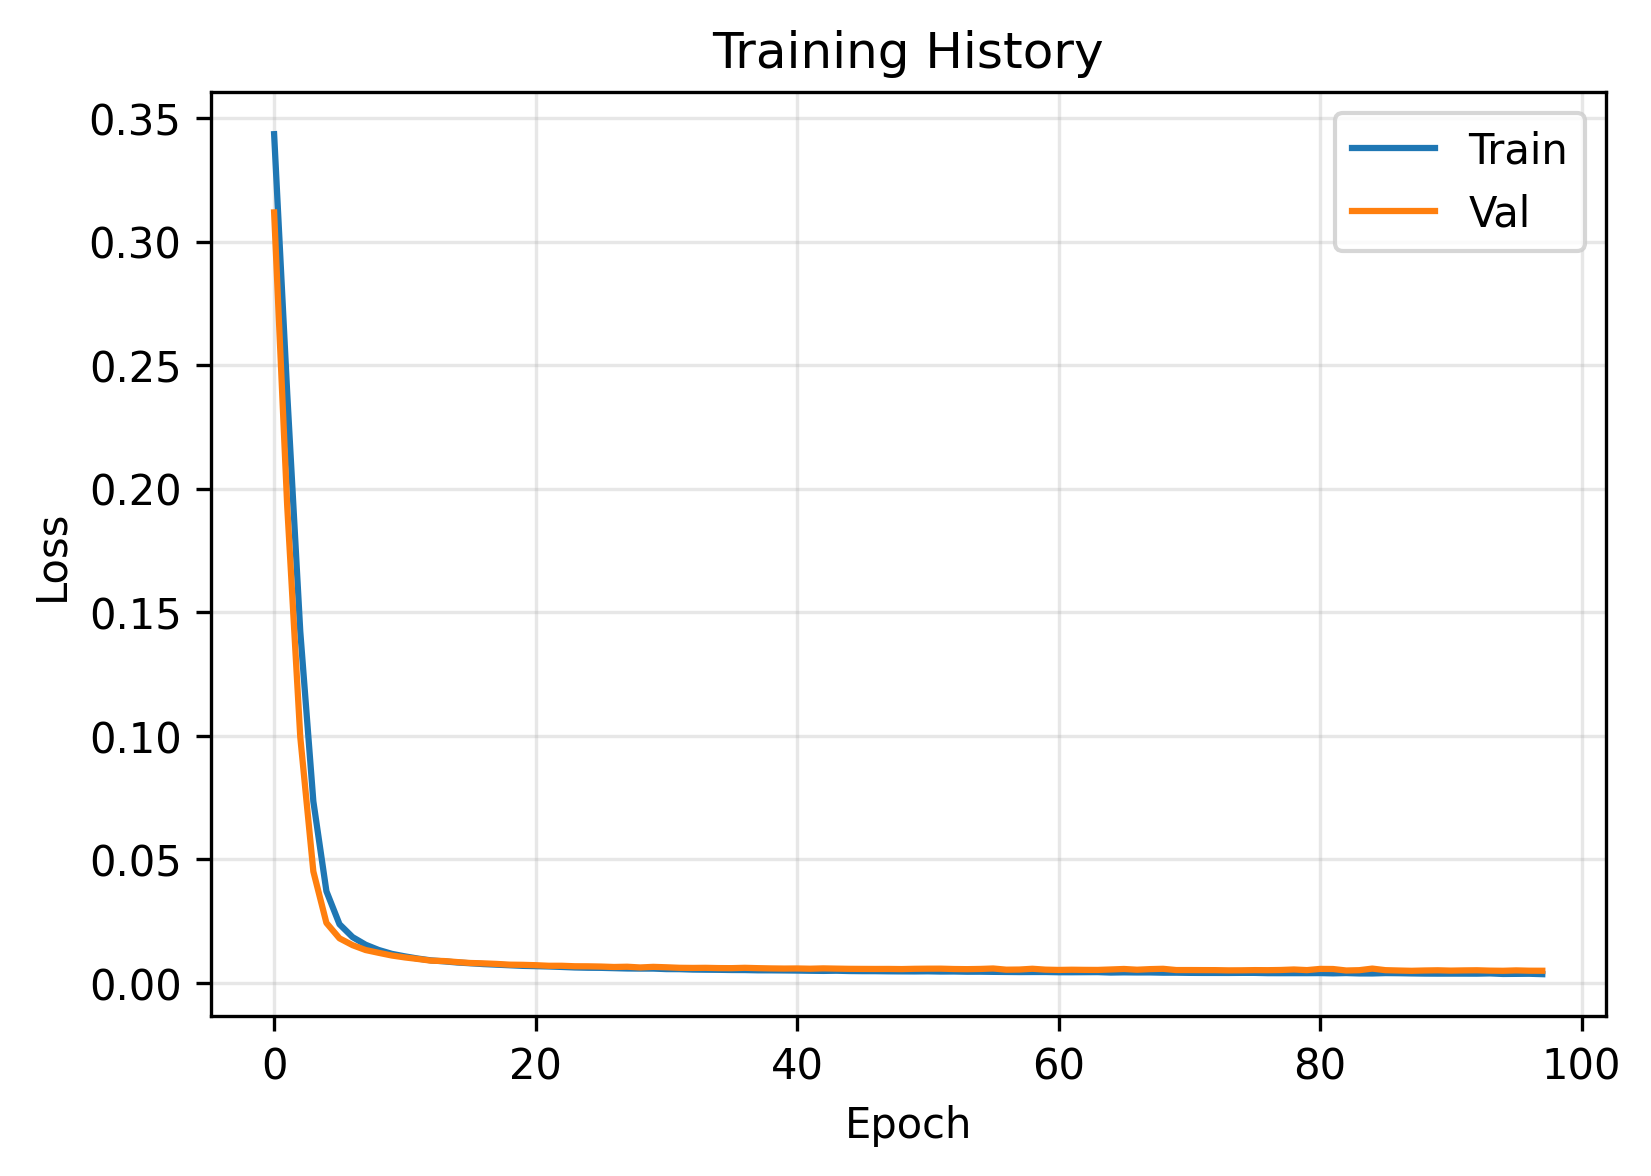

CPU times: user 801 ms, sys: 85.8 ms, total: 887 ms
Wall time: 1.03 s


In [9]:
%%time

fit_config = remu.FitConfig(
    epochs=200,
    device="cpu",
    early_stopping_patience=10,
    gradient_clipping=None,
)

model = remu.FourParamEmulator()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

history = remu.fit(
    model=model,
    train_loader=loaders["train"],
    val_loader=loaders["val"],
    optimizer=optimizer,
    loss_fn=loss_fn,
    config=fit_config,
)

print(type(history))
print(history.keys())
print("Epochs Recorded:", len(history["train_loss"]))
print("Best Val Loss:", min(history["val_loss"]))

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. K-Fold cross-validation

The package also exposes a higher-level K-Fold CV utility that repeatedly rebuilds/train/evaluates fresh models across folds.

### Main function
- `remu.kfold_cross_validate(...)`

### Main config
- `remu.KFoldConfig(...)`

### Return object
A `dict` containing:

- `"ell"` — ell bin centers
- `"fold_best_val"` — list of best validation losses per fold
- `"mean_best_val"` — mean best validation loss
- `"std_best_val"` — standard deviation of best validation loss
- `"histories"` — optional, included when `return_histories=True`


=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.264822, val=0.211868
Epoch 002: train=0.172093, val=0.132431
Epoch 003: train=0.104958, val=0.081431
Epoch 004: train=0.058467, val=0.044614
Epoch 005: train=0.030174, val=0.024615
Epoch 006: train=0.018350, val=0.017730
Epoch 007: train=0.014627, val=0.015173
Epoch 008: train=0.012473, val=0.013515
Epoch 009: train=0.011510, val=0.013761
Epoch 010: train=0.010602, val=0.012015
Epoch 011: train=0.009838, val=0.011453
Epoch 012: train=0.009359, val=0.010998
Epoch 013: train=0.009044, val=0.010529
Epoch 014: train=0.008863, val=0.010475
Epoch 015: train=0.008246, val=0.010348
Epoch 016: train=0.007962, val=0.010034
Epoch 017: train=0.007807, val=0.009613
Epoch 018: train=0.007633, val=0.009241
Epoch 019: train=0.007278, val=0.009458
Epoch 020: train=0.007265, val=0.008815
Epoch 021: train=0.006955, val=0.008482
Epoch 022: train=0.006772, val=0.008757
Epoch 023: train=0.006692, val=0.008020
Epoch 024: train=0.006582, val=0.007897
Ep

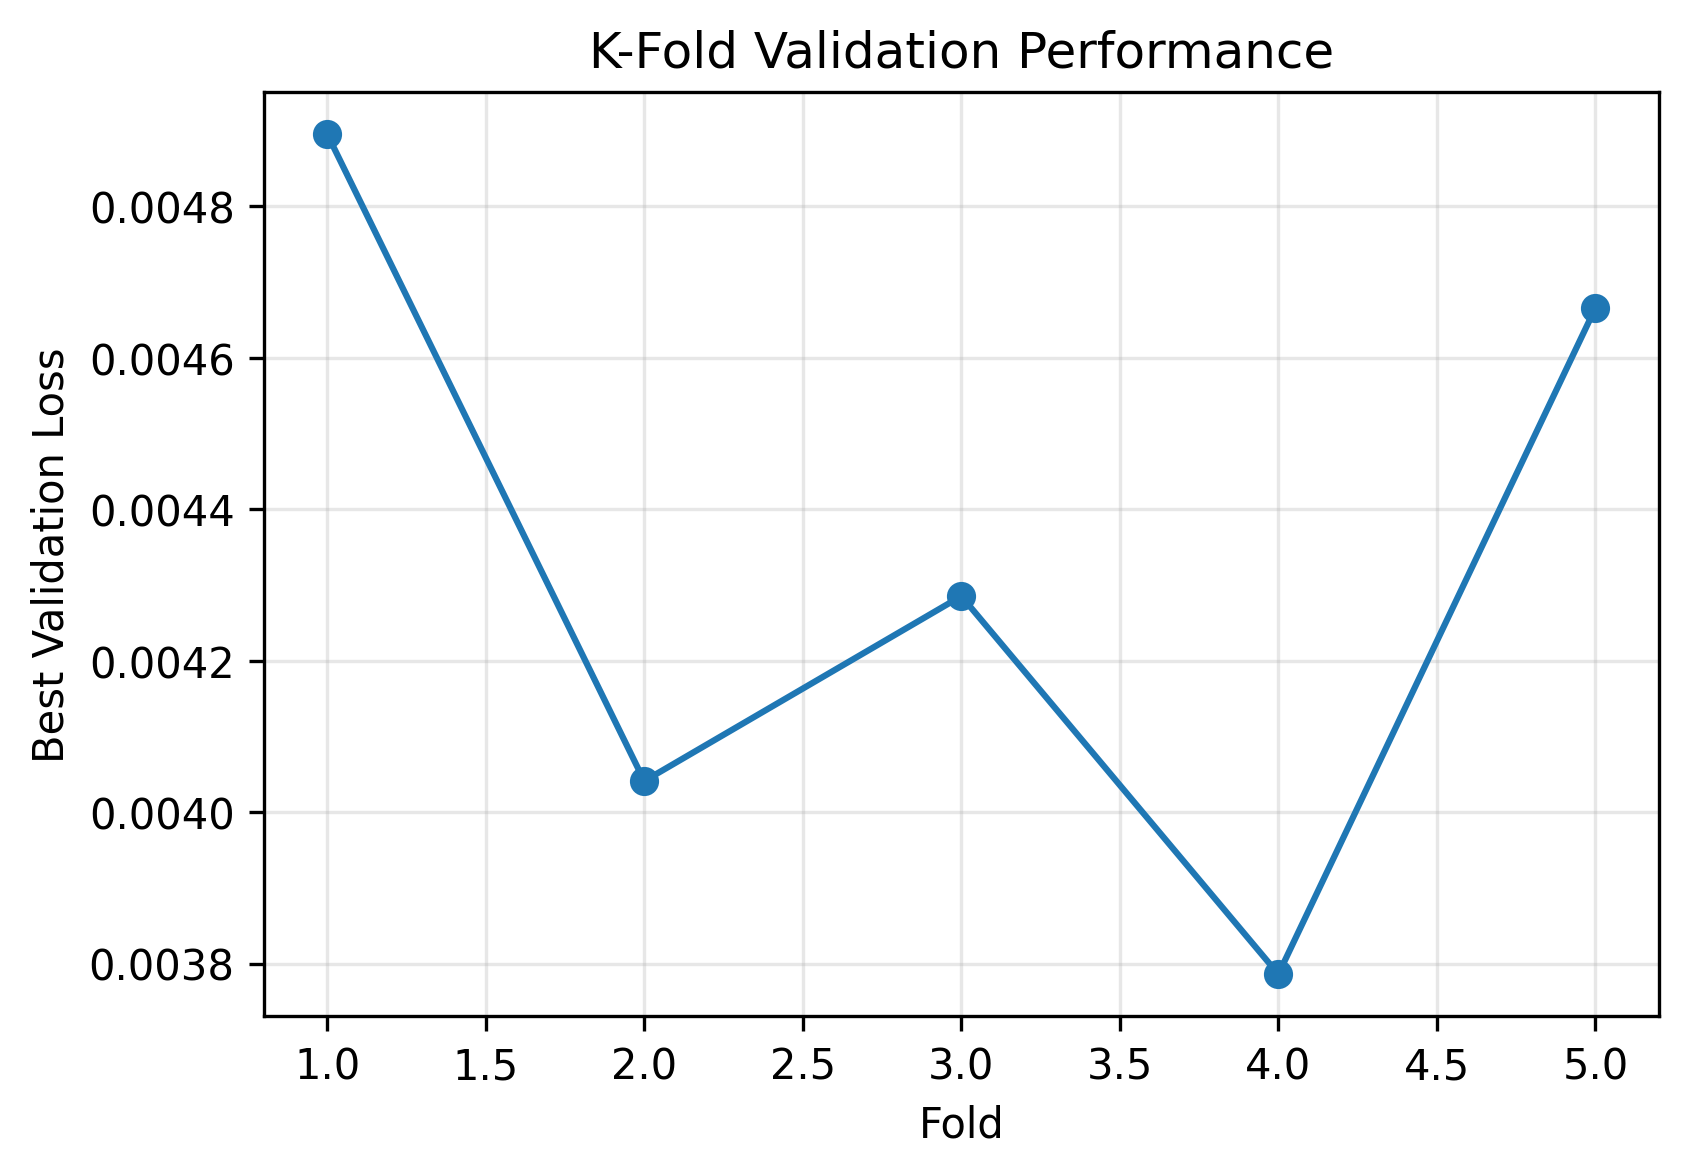

CPU times: user 2.56 s, sys: 18.4 ms, total: 2.58 s
Wall time: 2.58 s


In [10]:
%%time

kfold_config = remu.KFoldConfig(
    k=5,
    seed=42,
    return_histories=True,
)

cv_result = remu.kfold_cross_validate(
    h5_path=condensed_h5,
    model_builder=lambda: remu.FourParamEmulator(),
    optimizer_builder=lambda model: torch.optim.Adam(model.parameters(), lr=1e-3),
    loss_fn=torch.nn.MSELoss(),
    kfold_config=kfold_config,
    dl_config=dl_config,
    fit_config=fit_config,
)

print(type(cv_result))
print(cv_result.keys())
print("ell Shape:", cv_result["ell"].shape)
print("Fold Best Val Losses:", cv_result["fold_best_val"])
print("Mean Best Val:", cv_result["mean_best_val"])
print("STD Best Val:", cv_result["std_best_val"])
print("Number of Histories:", len(cv_result["histories"]))

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cv_result["fold_best_val"]) + 1), cv_result["fold_best_val"], marker="o")
plt.xlabel("Fold")
plt.ylabel("Best Validation Loss")
plt.title("K-Fold Validation Performance")
plt.grid(True, alpha=0.3)
plt.show()